# GARCH

In [ ]:
dataset_2014_cleaned.set_index('Date', inplace=True)
dataset_2014_cleaned.index = pd.to_datetime(dataset_2014_cleaned.index)


KeyError: "None of ['Date'] are in the columns"

In [ ]:
from arch import arch_model

df = dataset_2014_cleaned.copy()

# Используем ТОЛЬКО то, что нужно для DCC
data = df[['Gold', 'GDM']].dropna()
data.columns = ['gold', 'mining']

In [ ]:
garch_gold = arch_model(
    data['gold'],
    mean='Constant',
    vol='Garch',
    p=1, q=1,
    dist='normal'
)
res_gold = garch_gold.fit(disp='off')
print(res_gold.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   gold   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                15044.7
Distribution:                  Normal   AIC:                          -30081.5
Method:            Maximum Likelihood   BIC:                          -30055.6
                                        No. Observations:                 4712
Date:                Fri, May 08 2026   Df Residuals:                     4711
Time:                        15:18:22   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         3.0087e-04  1.328e-04      2.266  2.345e-02 [4.

In [ ]:
garch_mining = arch_model(
    data['mining'],
    mean='Constant',
    vol='Garch',
    p=1, q=2,
    dist='t'
)
res_mining = garch_mining.fit(disp='off')
print(res_mining.summary())


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       mining   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                11545.0
Distribution:      Standardized Student's t   AIC:                          -23078.0
Method:                  Maximum Likelihood   BIC:                          -23039.3
                                              No. Observations:                 4712
Date:                      Fri, May 08 2026   Df Residuals:                     4711
Time:                              15:18:22   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

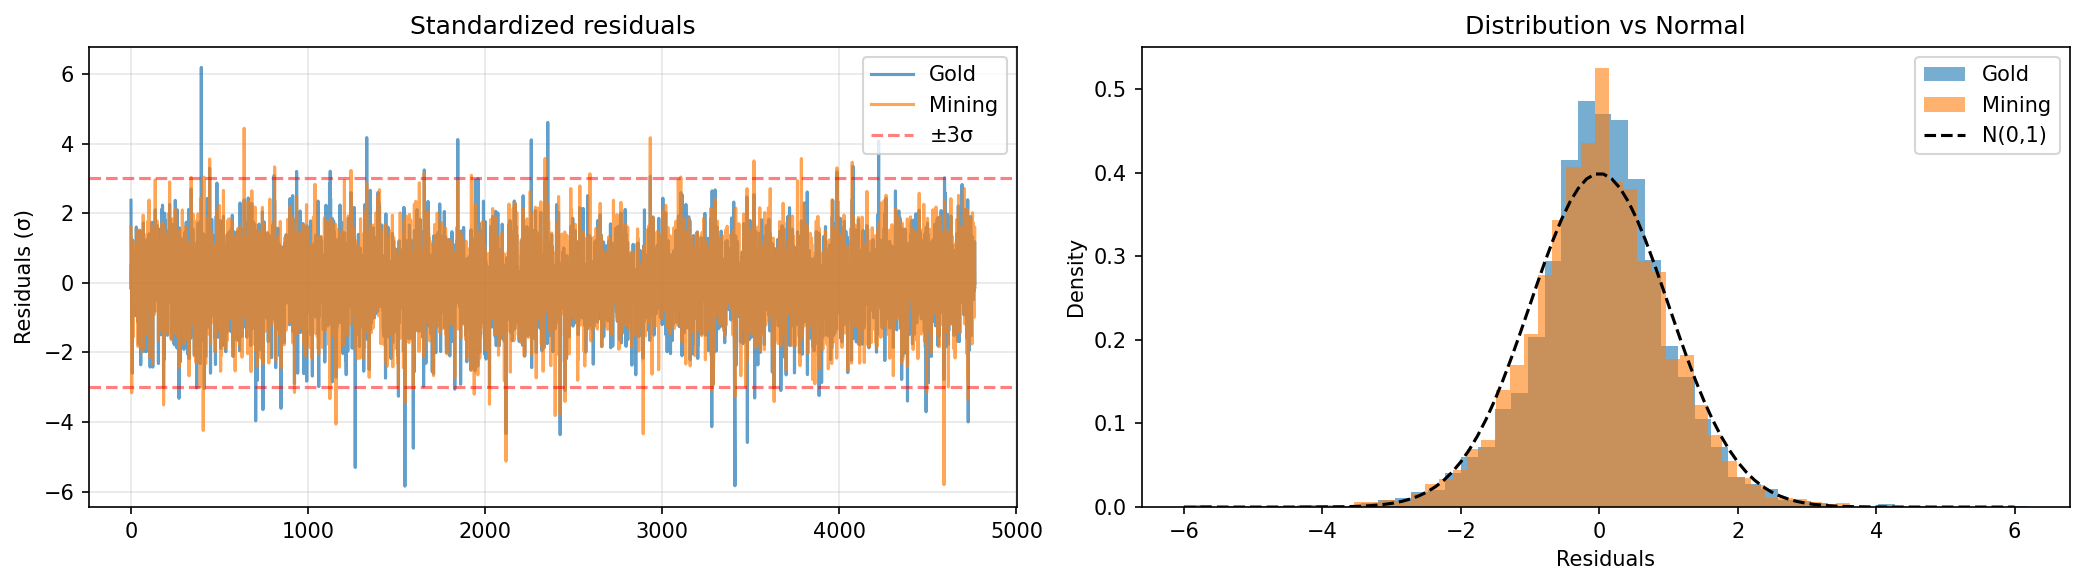

In [ ]:
# Добавьте статистический анализ к визуализации
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# 1. График остатков
ax1.plot(res_gold.std_resid, label='Gold', alpha=0.7)
ax1.plot(res_mining.std_resid, label='Mining', alpha=0.7)
ax1.axhline(y=3, color='r', linestyle='--', alpha=0.5, label='±3σ')
ax1.axhline(y=-3, color='r', linestyle='--', alpha=0.5)
ax1.legend()
ax1.set_title('Standardized residuals')
ax1.set_ylabel('Residuals (σ)')
ax1.grid(True, alpha=0.3)

# 2. Гистограмма с нормальным распределением
ax2.hist(res_gold.std_resid, bins=50, density=True, alpha=0.6, label='Gold')
ax2.hist(res_mining.std_resid, bins=50, density=True, alpha=0.6, label='Mining')

# Нормальное распределение для сравнения
x = np.linspace(-6, 6, 100)
ax2.plot(x, stats.norm.pdf(x, 0, 1), 'k--', label='N(0,1)')
ax2.legend()
ax2.set_title('Distribution vs Normal')
ax2.set_xlabel('Residuals')
ax2.set_ylabel('Density')

plt.tight_layout()
plt.show()

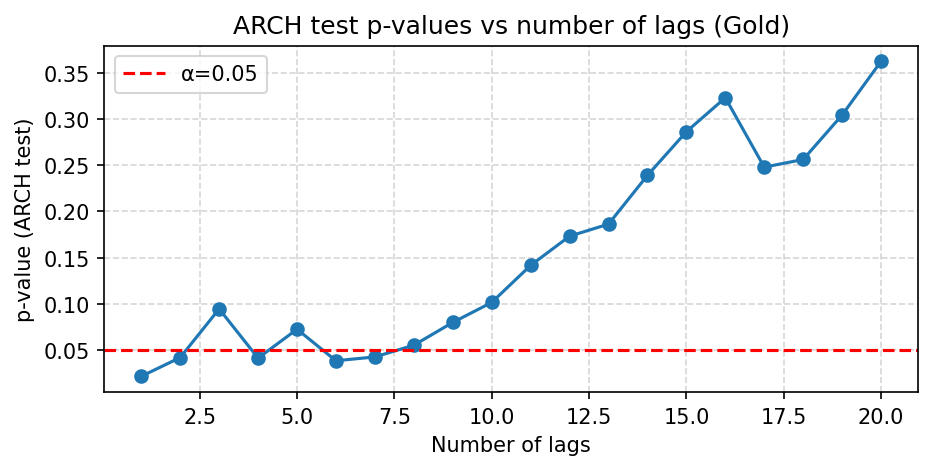

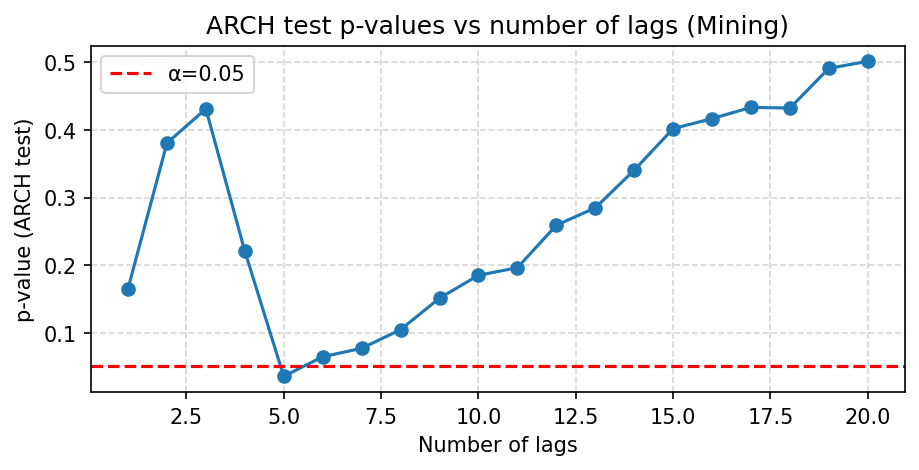

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import acf

# res_std_resid — стандартные остатки вашей модели GARCH или просто ошибки
# например: res_std_resid = res_gold.std_resid

def optimal_arch_lags(name, res_std_resid, max_lags=20, alpha=0.05, plot=True):
    """
    Подбираем оптимальное число лагов для теста ARCH.
    
    Parameters:
    -----------
    res_std_resid : array-like
        Стандартные остатки.
    max_lags : int
        Максимальное количество лагов для проверки.
    alpha : float
        Уровень значимости для теста (обычно 0.05).
    plot : bool
        Построить график p-value в зависимости от числа лагов.
        
    Returns:
    --------
    DataFrame с p-value для каждого числа лагов
    """
    results = []
    for nl in range(1, max_lags + 1):
        _, pvalue, _, _ = het_arch(res_std_resid, nlags=nl)
        results.append({"lags": nl, "p_value": pvalue})
    
    df = pd.DataFrame(results)
    
    if plot:
        plt.figure(figsize=(7,3))
        plt.plot(df['lags'], df['p_value'], marker='o', linestyle='-')
        plt.axhline(y=alpha, color='red', linestyle='--', label=f"α={alpha}")
        plt.xlabel("Number of lags")
        plt.ylabel("p-value (ARCH test)")
        plt.title(f"ARCH test p-values vs number of lags ({name})")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()
    
    return df

# Пример использования
df_lags_gold = optimal_arch_lags('Gold', res_gold.std_resid, max_lags=20)
df_lags_mining = optimal_arch_lags('Mining', res_mining.std_resid, max_lags=20)


In [ ]:
def check_residuals_for_dcc(res_gold, res_mining, threshold=3):
    """Полная проверка остатков для DCC-GARCH"""
    print("=" * 60)
    print("ПРОВЕРКА ОСТАТКОВ ДЛЯ DCC-GARCH")
    print("=" * 60)
    
    results = {
        'gold': {'pass': True, 'issues': []},
        'mining': {'pass': True, 'issues': []}
    }
    
    # Проверка 1: Среднее ~0
    print("\n1. Проверка среднего значения:")
    for name, res in [('Gold', res_gold.std_resid), ('Mining', res_mining.std_resid)]:
        mean_val = res.mean()
        if abs(mean_val) > 0.1:
            print(f"  {name}: mean={mean_val:.4f} ❌ Далеко от 0")
            results[name.lower()]['issues'].append(f"Среднее {mean_val:.4f} ≠ 0")
        else:
            print(f"  {name}: mean={mean_val:.4f} ✅ OK")
    
    # Проверка 2: Дисперсия ~1
    print("\n2. Проверка дисперсии:")
    for name, res in [('Gold', res_gold.std_resid), ('Mining', res_mining.std_resid)]:
        var_val = res.var()
        if abs(var_val - 1) > 0.2:
            print(f"  {name}: var={var_val:.4f} ❌ Далеко от 1")
            results[name.lower()]['issues'].append(f"Дисперсия {var_val:.4f} ≠ 1")
        else:
            print(f"  {name}: var={var_val:.4f} ✅ OK")
    
    # Проверка 3: Выбросы (>3σ)
    print("\n3. Проверка выбросов (>3σ):")
    for name, res in [('Gold', res_gold.std_resid), ('Mining', res_mining.std_resid)]:
        outliers = np.abs(res) > threshold
        percent = outliers.sum() / len(res) * 100
        
        if percent > 1:
            print(f"  {name}: {outliers.sum()} выбросов ({percent:.2f}%) ⚠️  Много")
            if percent > 5:
                results[name.lower()]['issues'].append(f"Много выбросов: {percent:.1f}%")
        else:
            print(f"  {name}: {outliers.sum()} выбросов ({percent:.2f}%) ✅ OK")
    
    # Проверка 4: ARCH эффекты
    print("\n4. Проверка ARCH эффектов (кластеризация волатильности):")
    for name, res, lags in [('Gold', res_gold.std_resid,8), ('Mining', res_mining.std_resid, 6)]:
        _, p_value, _, _ = het_arch(res, nlags=lags)
        
        if p_value < 0.05:
            print(f"  {name}: p={p_value:.4f} ❌ Есть ARCH эффекты")
            results[name.lower()]['issues'].append(f"ARCH эффекты (p={p_value:.4f})")
        else:
            print(f"  {name}: p={p_value:.4f} ✅ Нет ARCH эффектов")
    
    # Итоговая оценка
    print("\n" + "=" * 60)
    print("ИТОГОВАЯ ОЦЕНКА:")
    print("=" * 60)
    
    all_pass = True
    for name in ['gold', 'mining']:
        if results[name]['issues']:
            print(f"\n❌ {name.capitalize()}: НЕ ГОТОВО для DCC")
            print(f"   Проблемы: {', '.join(results[name]['issues'])}")
            all_pass = False
        else:
            print(f"\n✅ {name.capitalize()}: ГОТОВО для DCC")
    
    if all_pass:
        print("\n🎉 ВСЕ ОСТАТКИ ПРОШЛИ ПРОВЕРКУ! Можете использовать DCC-GARCH.")
    else:
        print("\n⚠️  Есть проблемы. Рекомендуется:")
        print("   - Проверить спецификацию GARCH моделей")
        print("   - Увеличить порядки GARCH(p,q)")
        print("   - Добавить асимметричные эффекты (GJR-GARCH)")
    
    return results

# Запускаем проверку
results = check_residuals_for_dcc(res_gold, res_mining)

ПРОВЕРКА ОСТАТКОВ ДЛЯ DCC-GARCH

1. Проверка среднего значения:
  Gold: mean=0.0087 ✅ OK
  Mining: mean=-0.0093 ✅ OK

2. Проверка дисперсии:
  Gold: var=0.9661 ✅ OK
  Mining: var=0.9901 ✅ OK

3. Проверка выбросов (>3σ):
  Gold: 40 выбросов (0.85%) ✅ OK
  Mining: 38 выбросов (0.81%) ✅ OK

4. Проверка ARCH эффектов (кластеризация волатильности):
  Gold: p=0.0552 ✅ Нет ARCH эффектов
  Mining: p=0.0645 ✅ Нет ARCH эффектов

ИТОГОВАЯ ОЦЕНКА:

✅ Gold: ГОТОВО для DCC

✅ Mining: ГОТОВО для DCC

🎉 ВСЕ ОСТАТКИ ПРОШЛИ ПРОВЕРКУ! Можете использовать DCC-GARCH.


In [ ]:
z_gold = res_gold.std_resid
z_mining = res_mining.std_resid

Z = np.column_stack([z_gold, z_mining])


In [ ]:
def dcc_correlation(Z, a=0.05, b=0.93):
    T, N = Z.shape
    Qbar = np.cov(Z.T)

    Qt = np.zeros((T, N, N))
    Rt = np.zeros((T, N, N))

    Qt[0] = Qbar

    for t in range(1, T):
        Qt[t] = (
            (1 - a - b) * Qbar
            + a * np.outer(Z[t-1], Z[t-1])
            + b * Qt[t-1]
        )

        D_inv = np.diag(1 / np.sqrt(np.diag(Qt[t])))
        Rt[t] = D_inv @ Qt[t] @ D_inv

    return Rt

Rt = dcc_correlation(Z)

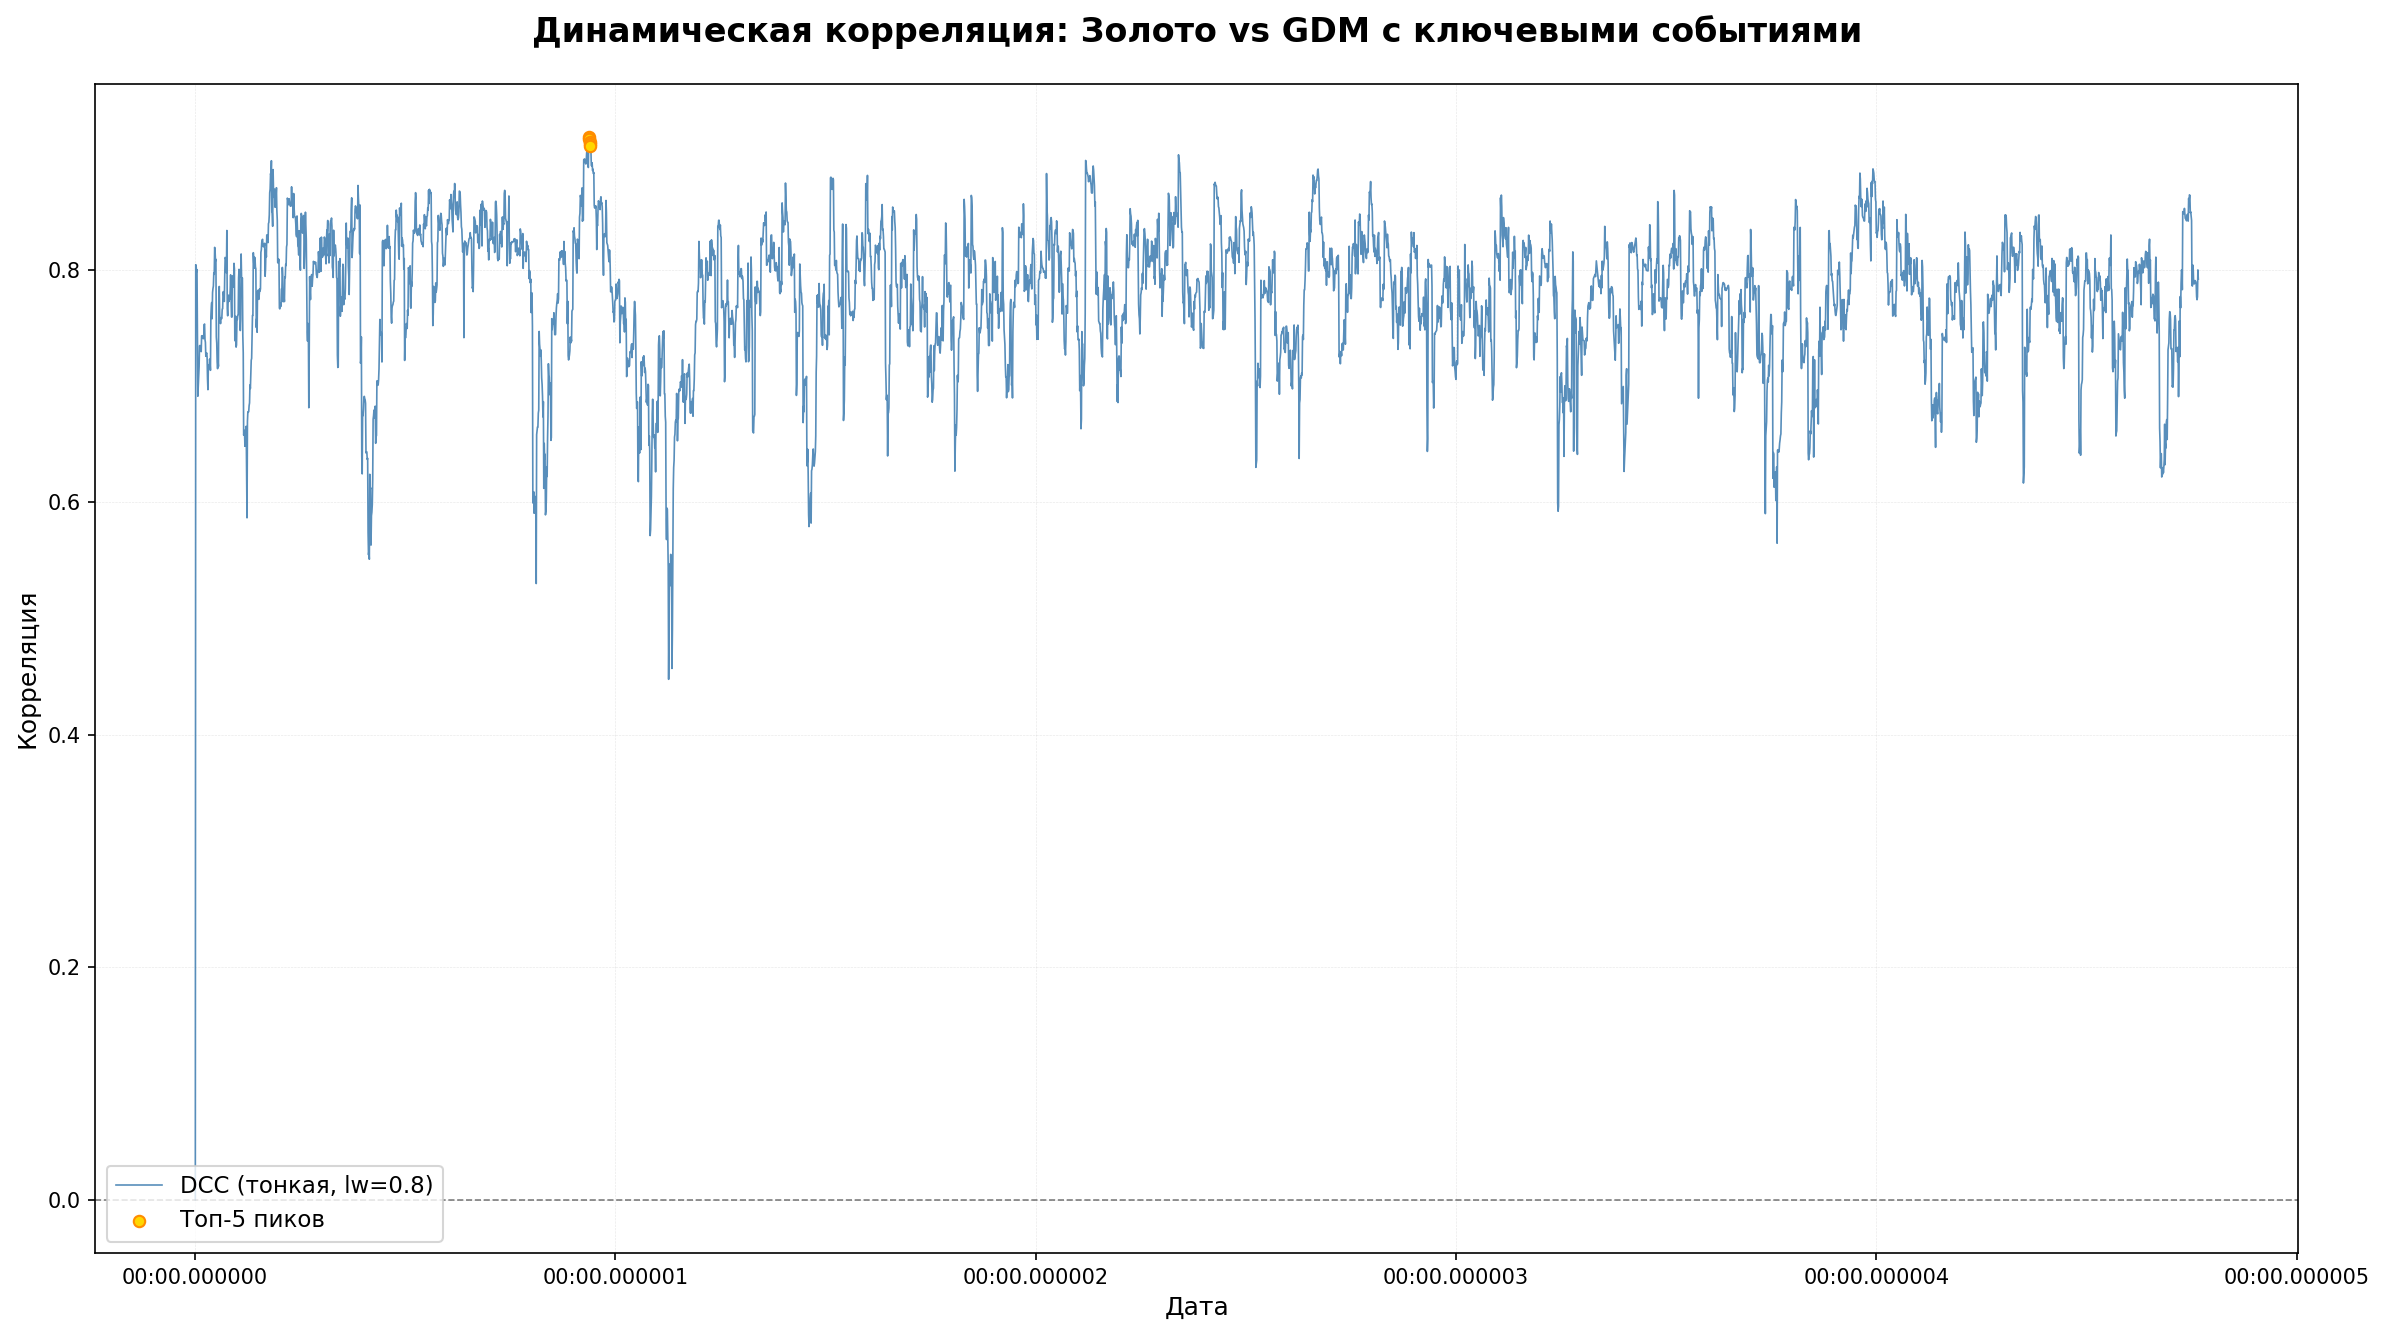

In [ ]:
dcc_corr = pd.Series(
    [Rt[t][0, 1] for t in range(len(Rt))],
    index=data.index
)
# Convert index to datetime for proper date operations
if not pd.api.types.is_datetime64_any_dtype(dcc_corr.index):
    # Try to parse from data's original dates
    try:
        dcc_corr.index = pd.to_datetime(dcc_corr.index)
    except:
        # If data.index was overwritten, reconstruct from original
        pass

import matplotlib.pyplot as plt
import pandas as pd

# --- 1. ОЧЕНЬ ВАЖНО: устанавливаем высокий DPI перед созданием фигуры ---
plt.rcParams['figure.dpi'] = 150  # или 200 для еще более четкого отображения

# --- 2. Создаем фигуру ---
fig, ax = plt.subplots(figsize=(16, 9))

# --- 3. Рисуем основную линию с РАЗНЫМИ толщинами для теста ---
# Давайте нарисуем ДВЕ линии для сравнения:
ax.plot(dcc_corr.index, dcc_corr.values,
        linewidth=0.8,  # ТОНКАЯ основная линия
        color='steelblue', 
        alpha=0.9,
        label='DCC (тонкая, lw=0.8)')

# --- 4. События с тонкими линиями ---
events = {
    '2008-09-29': 'Крах банков\nСША, паника',
    
    # Европейский долговой кризис
    '2011-08-05': 'Снижение рейтинга\nСША (S&P)',
    '2012-06-01': 'Пик кризиса\nеврозоны',
    
    # COVID-19 (массовая паника)
    '2020-03-16': 'COVID: ФРС экстренно\nснижает ставку',
    
    # Война в Украине (геополитика)
    '2022-02-24': 'Война в Украине\n(начало)'
}

# Convert event dates and check if within range
for event_date_str, label in events.items():
    event_date = pd.to_datetime(event_date_str)
    try:
        in_range = dcc_corr.index.min() <= event_date <= dcc_corr.index.max()
    except TypeError:
        # If index is int, convert to datetime by reconstructing from data
        print(f"Warning: index type is {type(dcc_corr.index[0])}, trying to convert...")
        try:
            original_dates = data.index  # data should have proper dates
            dcc_corr.index = original_dates
            in_range = dcc_corr.index.min() <= event_date <= dcc_corr.index.max()
        except:
            in_range = False
    
    if in_range:
        # ТОНКАЯ вертикальная линия
        ax.axvline(x=event_date, color='crimson',
                  linestyle=':', alpha=0.7, linewidth=0.8)  # ← было 1.5
        
        # Аннотация
        ax.annotate(label, 
           xy=(event_date, ax.get_ylim()[0]),  # ↓ СНИЗУ: берем нижнюю границу y (y.min)
           xytext=(0, -12),  # ↓ Отрицательное смещение ВНИЗ от точки
           textcoords='offset points',
           rotation=90, 
           ha='center', 
           va='top',  # ↓ Текст выравнивается ВВЕРХ от точки (то есть идет вниз)
           fontsize=9, 
           color='crimson', 
           alpha=0.9)

# --- 5. Пики с маленькими точками ---
N_PEAKS = 5
peak_indices = dcc_corr.values.argsort()[-N_PEAKS:][::-1]
peak_dates = dcc_corr.index[peak_indices]
peak_values = dcc_corr.values[peak_indices]

ax.scatter(peak_dates, peak_values,
          color='gold', s=30, edgecolor='darkorange', linewidth=1,  # s=30 вместо 50
          zorder=5, label=f'Топ-{N_PEAKS} пиков')

# --- 6. Настройки с ТОНКИМИ линиями ---
ax.set_title('Динамическая корреляция: Золото vs GDM с ключевыми событиями',
            fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Корреляция', fontsize=12)

# ТОНКАЯ горизонтальная линия
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)  # ← было 5

# ОЧЕНЬ тонкая сетка
ax.grid(True, which='both', linestyle='--', linewidth=0.3, alpha=0.3)  # ← было 0.5

ax.legend(loc='lower left', fontsize=11)

plt.tight_layout()
plt.show()


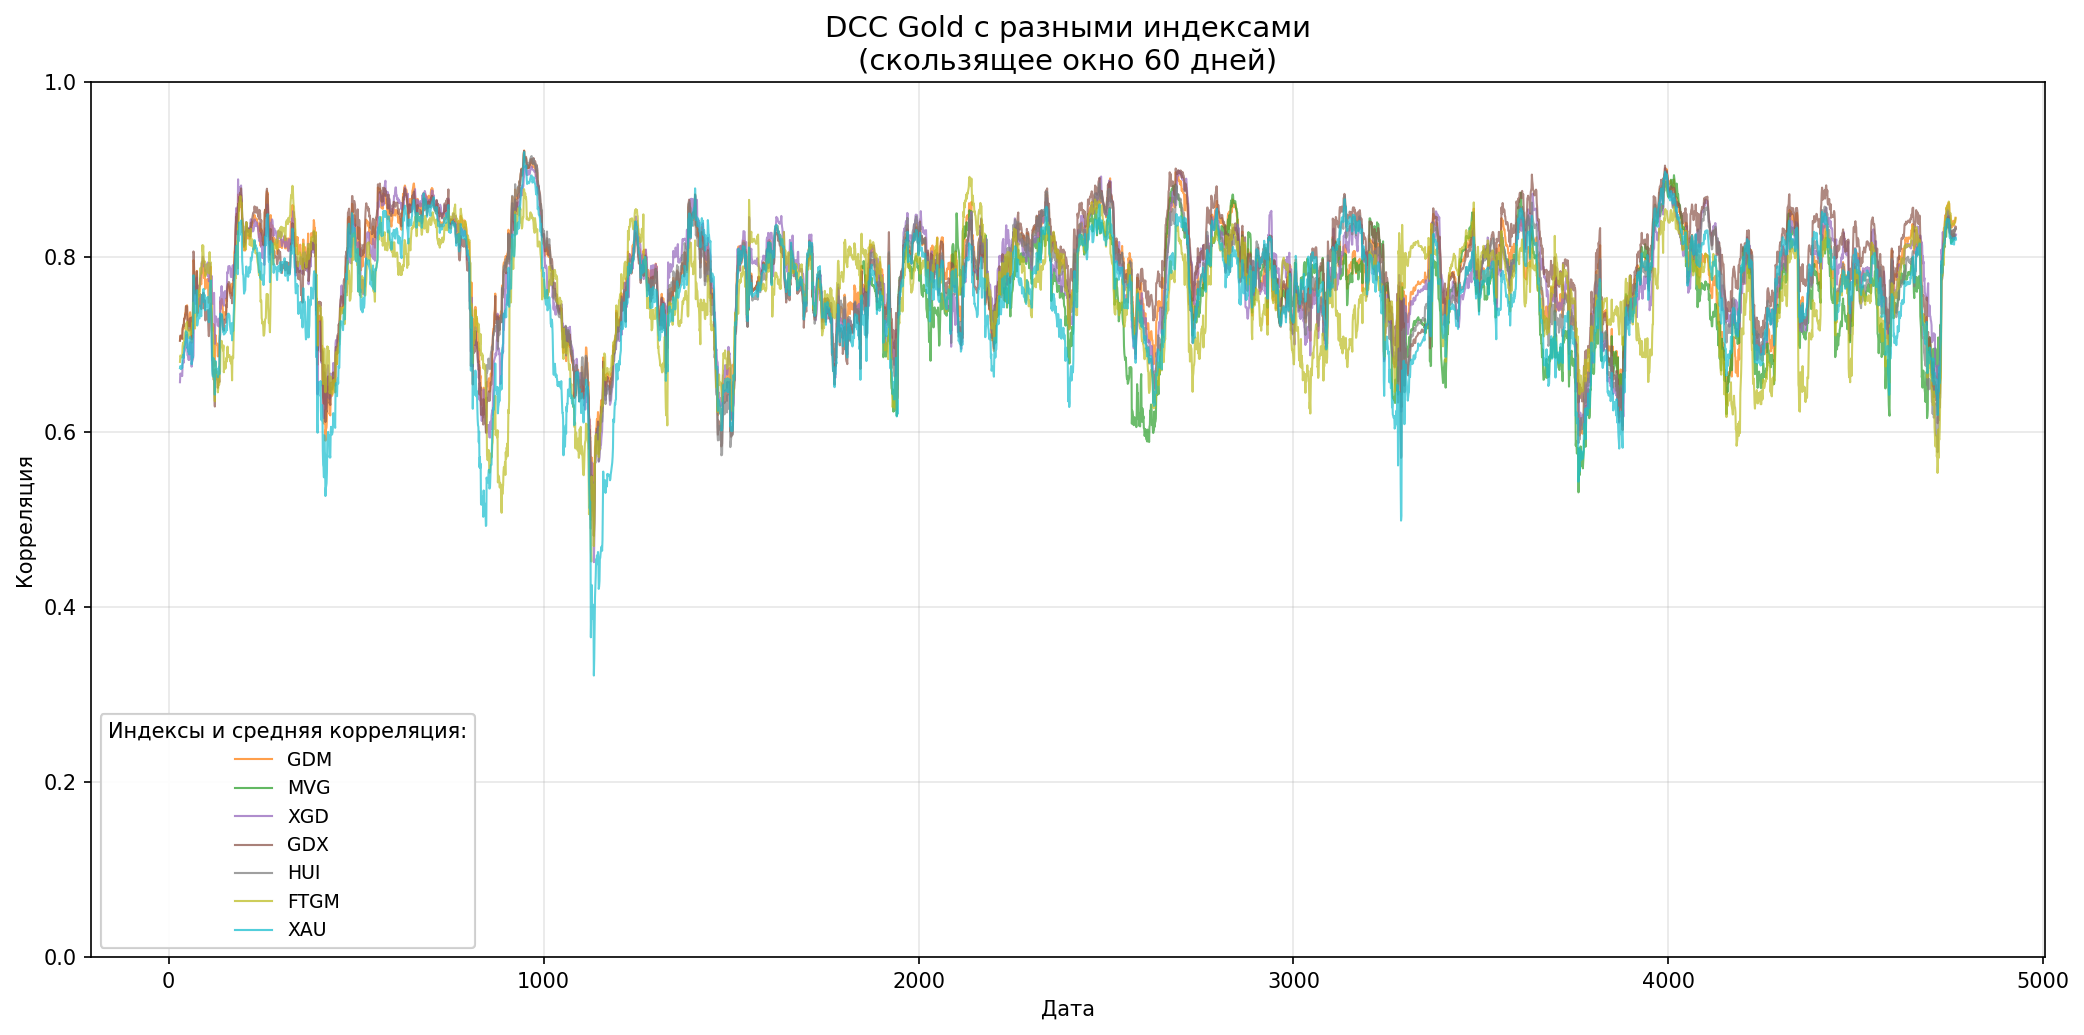

📊 СРЕДНИЕ КОРРЕЛЯЦИИ (весь период):
  GDM: 0.760
  MVG: 0.742
  XGD: 0.758
  GDX: 0.760
  HUI: 0.749
  FTGM: 0.747
  XAU: 0.729


In [ ]:
def plot_robustness_single_plot(data, gold_col='Gold', indices=None):
    """
    Robustness check: ВСЕ индексы на одном графике для сравнения
    """
    if indices is None:
        indices = ['JUNR', 'GDM', 'MVG', 'XGD', 'GDX', 'HUI', 'FTGM', 'XAU']
    
    plt.figure(figsize=(14, 7))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(indices)))
    legend_labels = []
    
    for i, idx in enumerate(indices):
        if idx not in data.columns:
            continue
            
        # 1. Объединяем Gold и индекс, удаляем строки где ХОТЯ БЫ ОДНО значение NaN
        pair_data = data[[gold_col, idx]].dropna()
        
        if len(pair_data) < 100:  # Минимум данных
            continue
        
        # 2. Скользящая корреляция (60 дней) - ТОЛЬКО ПО ОБЩИМ ДАТАМ
        rolling_corr = pair_data[gold_col].rolling(window=60, min_periods=30).corr(pair_data[idx])
        
        # 3. Рисуем
        plt.plot(rolling_corr.index, rolling_corr.values,
                linewidth=1.0, color=colors[i], alpha=0.7, label=f'{idx}')
        
        # 4. Средняя корреляция за весь период
        avg_corr = pair_data[gold_col].corr(pair_data[idx])
        legend_labels.append(f'{idx}: {avg_corr:.3f}')
    
    
    plt.title('DCC Gold с разными индексами\n(скользящее окно 60 дней)', fontsize=14)
    plt.xlabel('Дата')
    plt.ylabel('Корреляция')
    plt.ylim(0, 1)  # Корреляция от 0 до 1
    
    # Легенда с средними значениями
    legend1 = plt.legend(loc='lower left', fontsize=9, title='Индексы и средняя корреляция:')
    plt.gca().add_artist(legend1)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Выводим статистику
    print("📊 СРЕДНИЕ КОРРЕЛЯЦИИ (весь период):")
    print("="*45)
    for label in legend_labels:
        print(f"  {label}")

# Запускаем
plot_robustness_single_plot(dataset_2014_cleaned)